In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
data=pd.read_csv('DailyDelhiClimateTest.csv')

In [52]:
data=data[['date', 'meantemp']]
data

,date,meantemp
0,2017-01-01,15.913043
1,2017-01-02,18.500000
2,2017-01-03,17.111111
3,2017-01-04,18.700000
4,2017-01-05,18.388889
...,...,...
109,2017-04-20,34.500000
110,2017-04-21,34.250000
111,2017-04-22,32.900000
112,2017-04-23,32.875000


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      114 non-null    object 
 1   meantemp  114 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.9+ KB


In [59]:
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      114 non-null    datetime64[ns]
 1   meantemp  114 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.9 KB


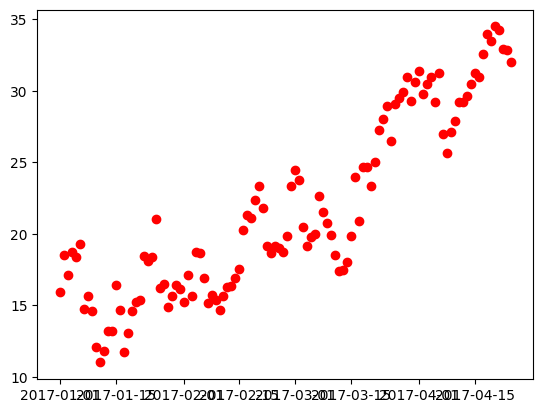

In [63]:
plt.scatter(data['date'], data['meantemp'], color="red")
plt.show()

In [64]:
x1=data['meantemp'].ewm(alpha=0.9).mean()

In [67]:
data['ewma']=x1

In [68]:
data

,date,meantemp,ewma
0,2017-01-01,15.913043,15.913043
1,2017-01-02,18.500000,18.264822
2,2017-01-03,17.111111,17.225443
3,2017-01-04,18.700000,18.552677
4,2017-01-05,18.388889,18.405266
...,...,...,...
109,2017-04-20,34.500000,34.403401
110,2017-04-21,34.250000,34.265340
111,2017-04-22,32.900000,33.036534
112,2017-04-23,32.875000,32.891153


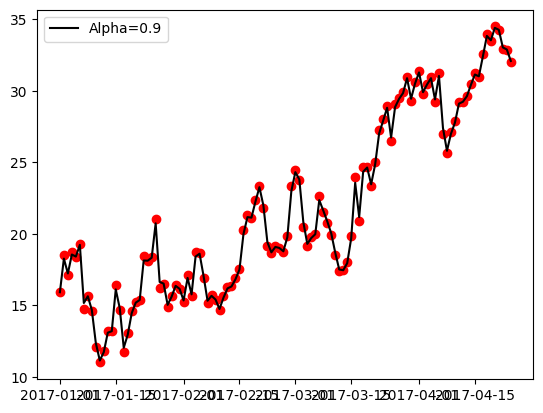

In [74]:
plt.scatter(data['date'], data['meantemp'], color="red")
plt.plot(data['date'], data['ewma'], c='black', label='Alpha=0.9')
plt.legend()
plt.show()

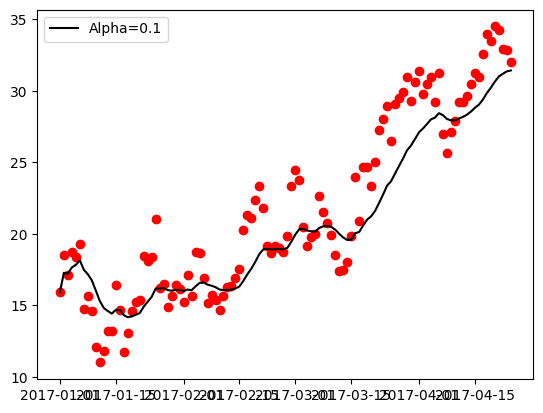

In [88]:
x1=data['meantemp'].ewm(alpha=0.1).mean()
plt.scatter(data['date'], data['meantemp'], color="red")
plt.plot(data['date'], x1, c='black', label='Alpha=0.1')
plt.legend()
plt.show()

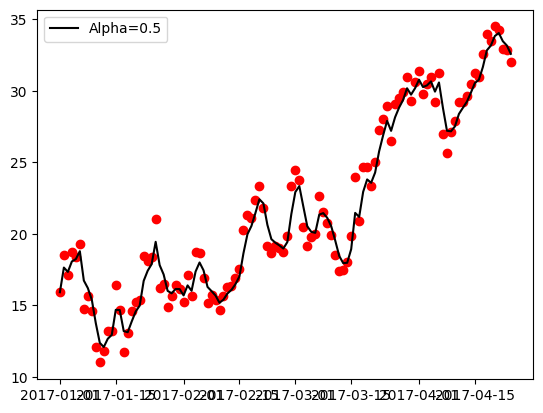

In [89]:
x1=data['meantemp'].ewm(alpha=0.5).mean()
plt.scatter(data['date'], data['meantemp'], color="red")
plt.plot(data['date'], x1, c='black', label='Alpha=0.5')
plt.legend()
plt.show()

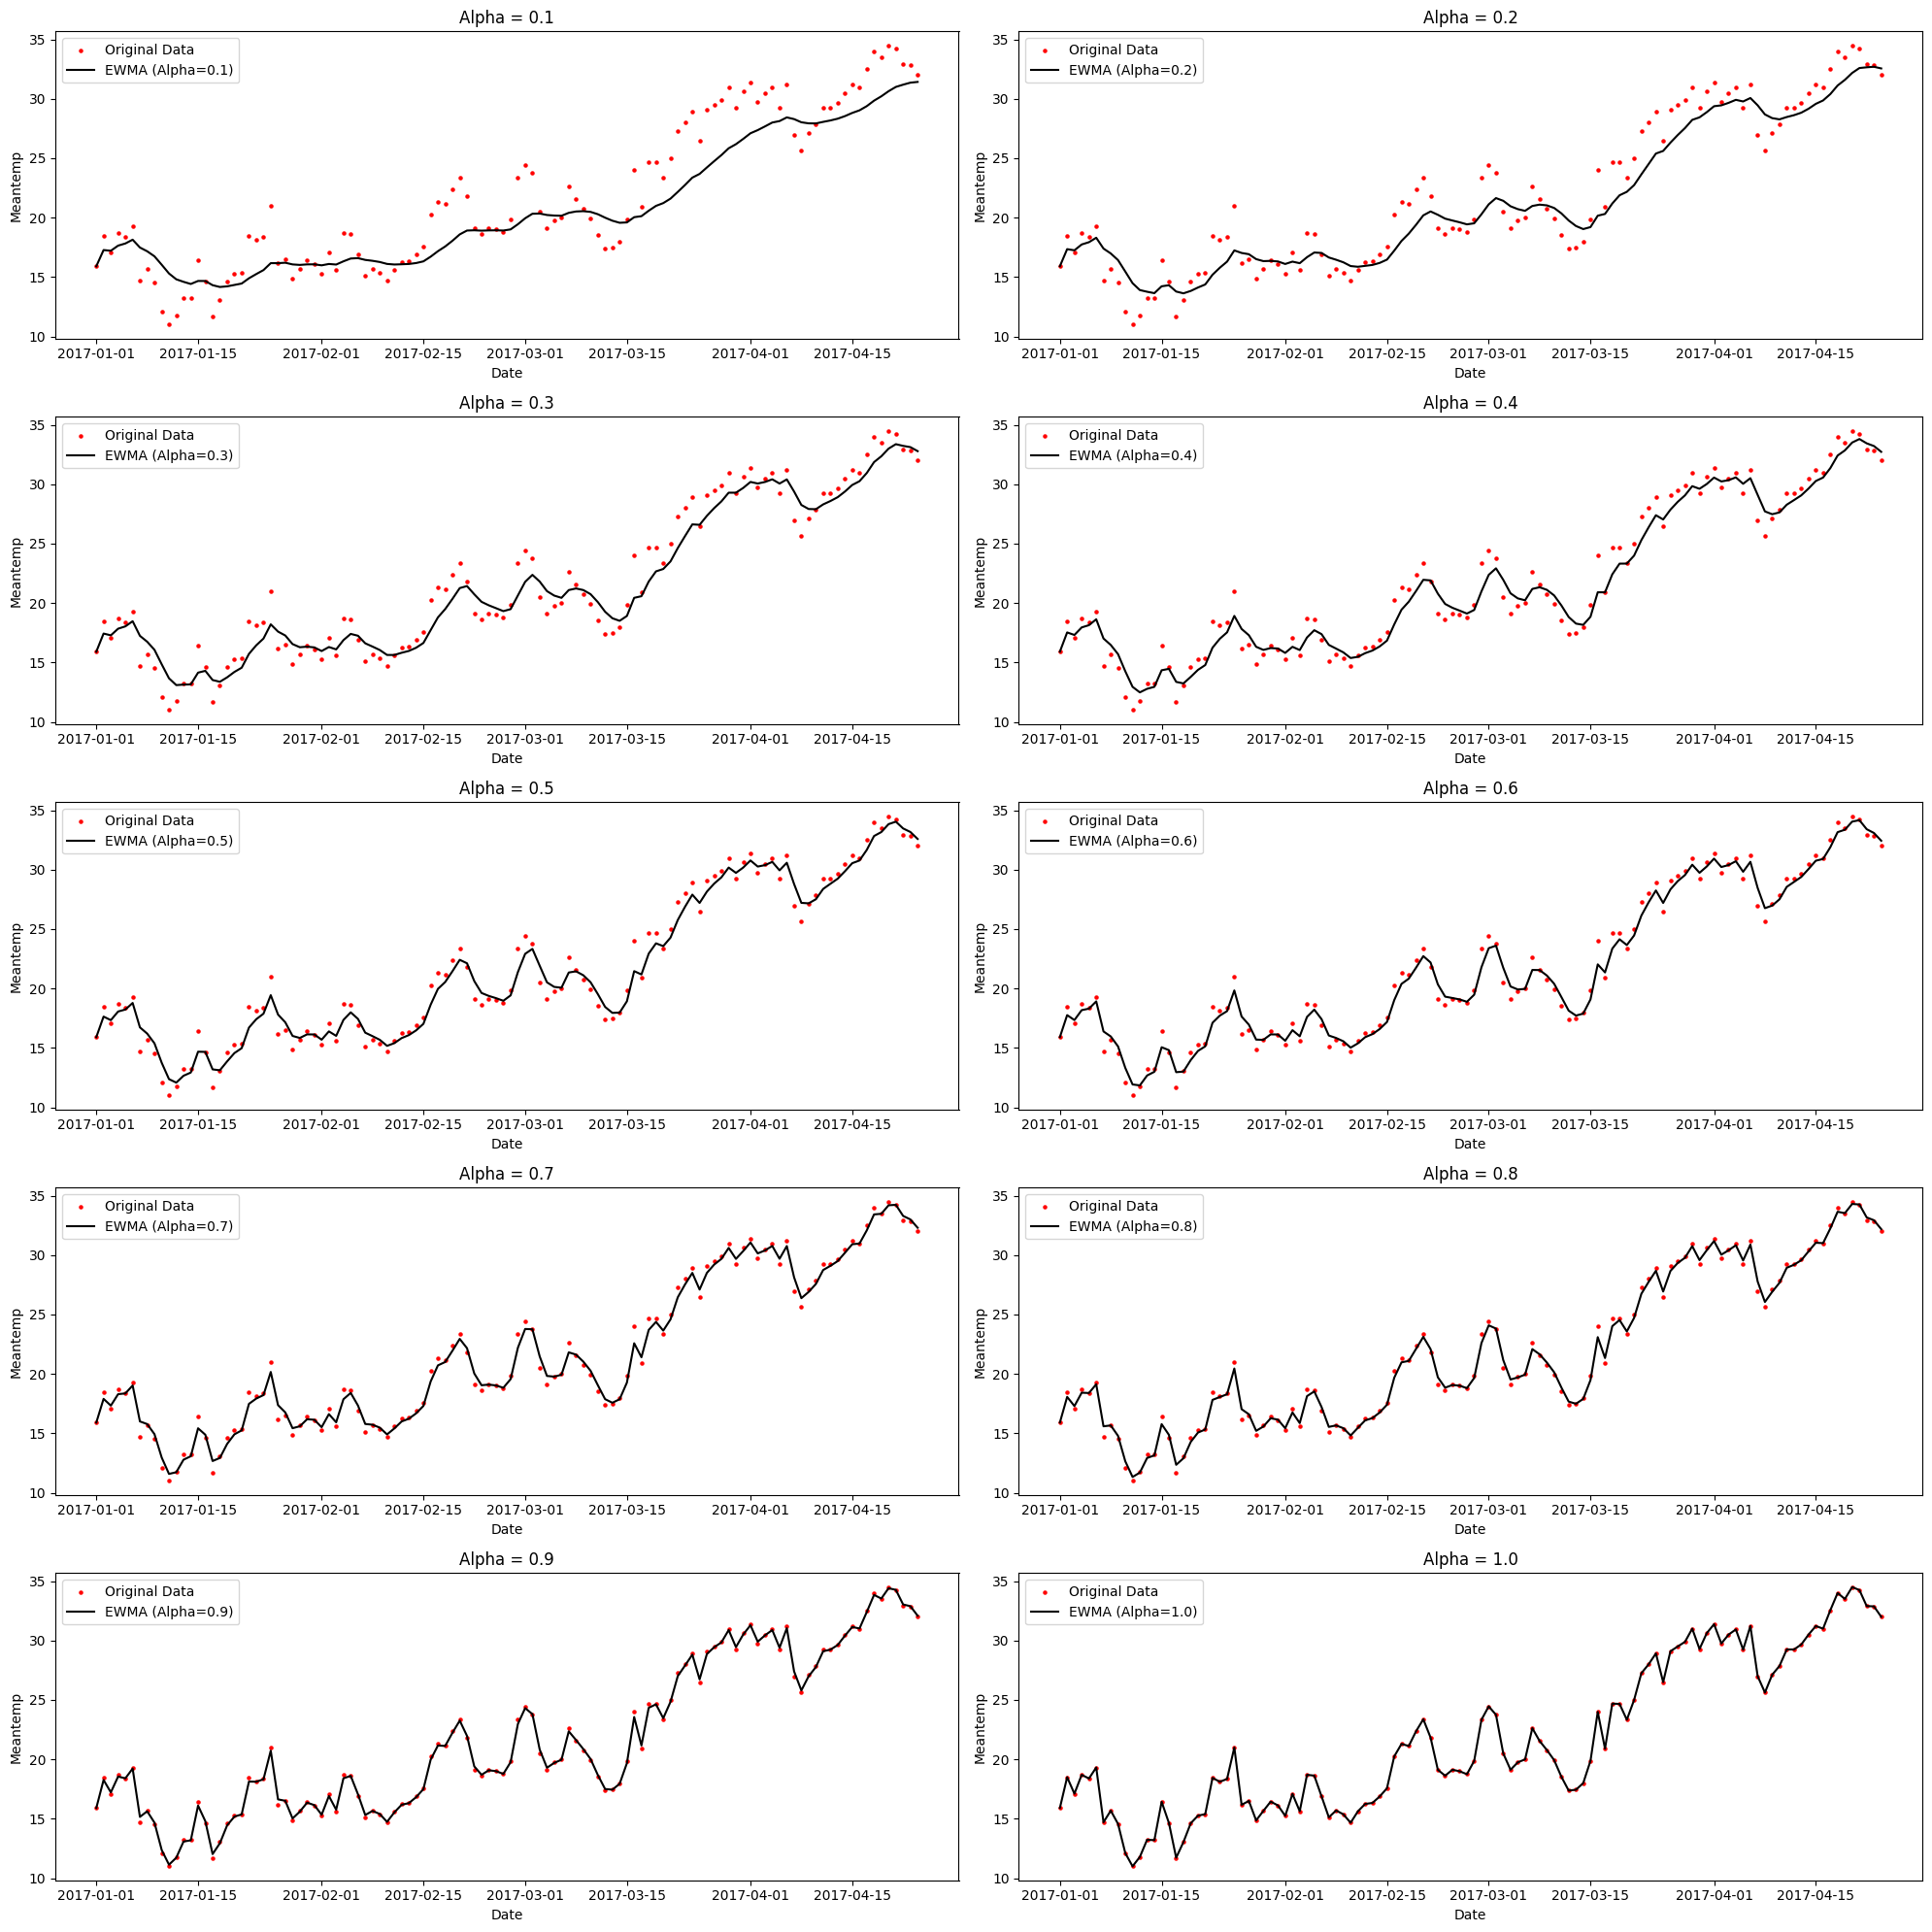

In [84]:
import numpy as np

# Changed to 5 rows and 2 columns to have 'only 2 images in a row' and accommodate all 9 alpha values
fig, axs = plt.subplots(5, 2, figsize=(20, 20)) # Adjusted figure size for new layout
axs = axs.flatten() # Flatten the array of axes for easier iteration

alpha_values = np.arange(0.1, 1.1, 0.1) # This generates 9 values

for idx, alpha in enumerate(alpha_values):
    if idx >= len(axs): # Stop if we run out of subplots (e.g., if alpha_values had more than 10)
        break

    current_ax = axs[idx]
    x1 = data['meantemp'].ewm(alpha=alpha).mean()

    current_ax.scatter(data['date'], data['meantemp'], color="red", s=5, label='Original Data')
    current_ax.plot(data['date'], x1, c='black', label=f'EWMA (Alpha={alpha:.1f})')
    current_ax.set_title(f'Alpha = {alpha:.1f}')
    current_ax.legend()
    current_ax.set_xlabel('Date') # Add x-label
    current_ax.set_ylabel('Meantemp') # Add y-label

# Remove any unused subplots if alpha_values is less than total subplots
for i in range(len(alpha_values), len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.show()